# Compression, pressure and jamming

This notebook follows a compression from a dilute gas to a jammed packing, compares the stopping criteria, and checks that the result is really jammed: a well-defined network of contacts that carries all the force.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/computational-chemical-engineering/spheropack/blob/main/docs/notebooks/02_compression_and_jamming.ipynb) [![Download notebook](https://img.shields.io/badge/download-notebook-orange?logo=jupyter)](https://computational-chemical-engineering.github.io/spheropack/notebooks/02_compression_and_jamming.ipynb)

In [ ]:
# Install spheropack when it is not available (for example on Google Colab).
import importlib.util

if importlib.util.find_spec("spheropack") is None:
    %pip install -q spheropack

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import spheropack as sp
from spheropack import analysis

## The course of a compression

`density="max"` grows the spheres until they jam. `history` holds one record per measurement window (10 collisions per sphere): the radius scale, the mean and median reduced pressure $Z = PV/(Nk_BT)$, the temperature and the phase of the jamming protocol.

In [2]:
p = sp.pack(n=2000, density="max", seed=1)
print(p)
h = p.history
phi = p.density * (h["scale"] / h["scale"][-1]) ** 3
print(f"{len(phi)} windows, {p.n_collisions / p.n:.0f} collisions per sphere, {p.wall_time:.1f} s")

Packing(n=2000, dim=3, density=0.640406, status='jammed', reduced_pressure=1.21e+09, n_collisions=8451446, seed=1)
394 windows, 4226 collisions per sphere, 30.8 s


At low density the pressure follows the equilibrium equation of state of hard spheres (Carnahan-Starling): the compression is slow compared with the collision rate. Near jamming the pressure diverges as $Z \approx 3/(1-\phi/\phi_J)$.

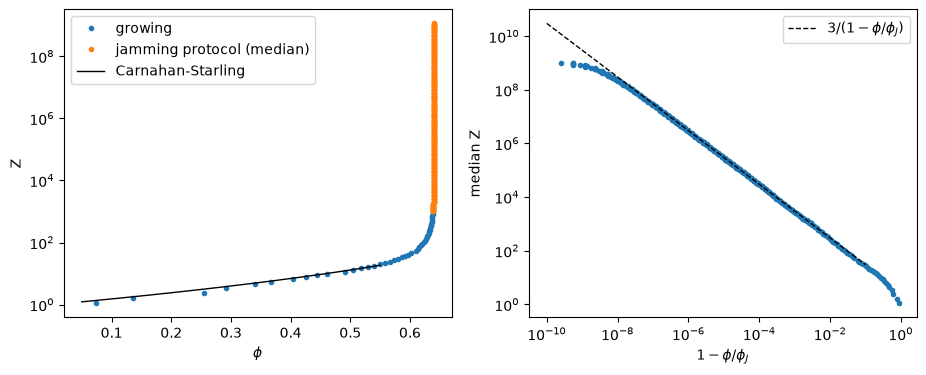

In [3]:
def carnahan_starling(phi):
    return (1 + phi + phi**2 - phi**3) / (1 - phi) ** 3

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
grow = h["phase"] == 0
ax.semilogy(phi[grow], h["reduced_pressure"][grow], ".", label="growing")
ax.semilogy(phi[~grow], h["median_pressure"][~grow], ".", label="jamming protocol (median)")
x = np.linspace(0.05, 0.55, 100)
ax.semilogy(x, carnahan_starling(x), "k-", lw=1, label="Carnahan-Starling")
ax.set_xlabel(r"$\phi$"); ax.set_ylabel("Z"); ax.legend()

ax = axes[1]
phi_j = p.density
ax.loglog(1 - phi / phi_j, h["median_pressure"], ".")
d = np.logspace(-10, -1, 10)
ax.loglog(d, 3 / d, "k--", lw=1, label=r"$3/(1-\phi/\phi_J)$")
ax.set_xlabel(r"$1 - \phi/\phi_J$"); ax.set_ylabel("median Z"); ax.legend();

## Is it jammed? Contacts and rattlers

Two spheres are in contact when their gap is below a tolerance. In a jammed packing at pressure $Z$ the gaps between touching spheres are of order $d/Z$, and much larger between spheres that do not touch, so the number of contacts has a plateau as a function of the tolerance.

The per-sphere pressure is the time-averaged contact force on a sphere. Spheres without force are *rattlers*: they sit loose in a cage of jammed neighbours. A frictionless jammed packing is *isostatic*: the force-bearing spheres have exactly as many contacts as needed for rigidity, $D(N_\mathrm{nr}-1)$ in a periodic box, so their mean coordination number is close to $2D = 6$.

rattlers: 80 of 2000 (4.0%)


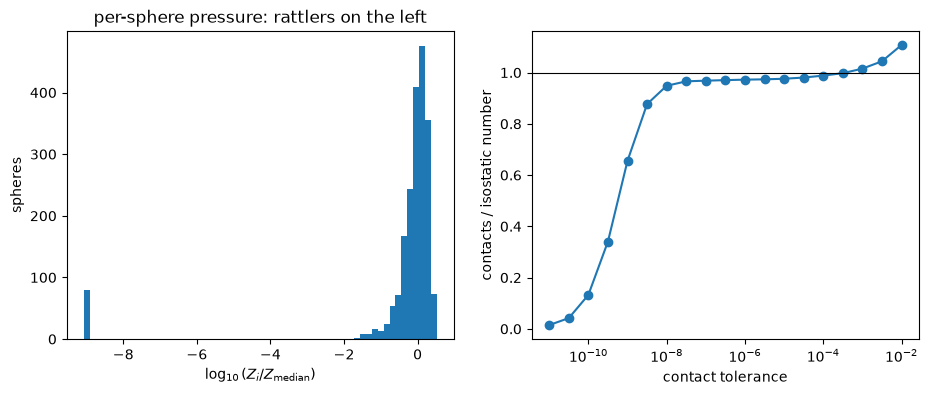

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(np.log10(p.sphere_pressure / p.median_pressure), bins=60)
axes[0].set_xlabel(r"$\log_{10}(Z_i / Z_\mathrm{median})$"); axes[0].set_ylabel("spheres")
axes[0].set_title("per-sphere pressure: rattlers on the left")

tols = np.logspace(-11, -2, 19)
iso = [analysis.isostaticity(p, t) for t in tols]
axes[1].semilogx(tols, iso, "o-")
axes[1].axhline(1, color="k", lw=0.8)
axes[1].set_xlabel("contact tolerance"); axes[1].set_ylabel("contacts / isostatic number")
rat = analysis.rattlers(p)
print(f"rattlers: {rat.sum()} of {p.n} ({100 * rat.mean():.1f}%)")

Below a tolerance of about $10^{-8}$ (the gap scale $d/Z$ at $Z=10^9$) contacts are missed; above about $10^{-4}$ near neighbours that do not touch are counted. In between lies the plateau, slightly below the isostatic number: a compression at a finite rate leaves a few percent of the contacts unformed. A slower protocol comes closer to 1 (see the user guide on stopping criteria).

## Pressure versus Jammed

`Pressure(value)` stops as soon as the mean pressure exceeds `value`, while the spheres keep growing. The density is almost the same, but the contact network is not yet formed: there is no plateau.

Packing(n=2000, dim=3, density=0.640188, status='pressure', reduced_pressure=1.04e+06, n_collisions=2452045, seed=1)


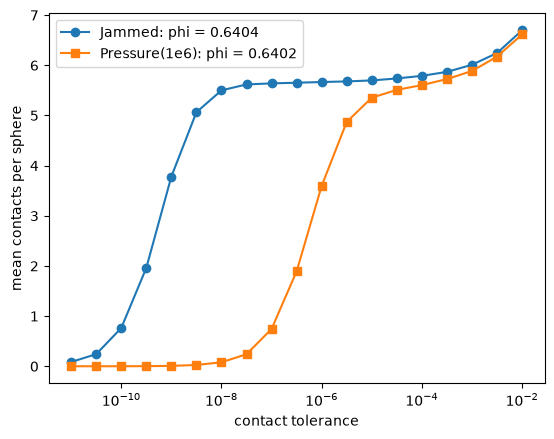

In [5]:
q = sp.pack(n=2000, density="max", stop=sp.stop.Pressure(1e6), seed=1)
print(q)
z_q = [analysis.contact_numbers(q, t).mean() for t in tols]
z_p = [analysis.contact_numbers(p, t).mean() for t in tols]
plt.semilogx(tols, z_p, "o-", label=f"Jammed: phi = {p.density:.4f}")
plt.semilogx(tols, z_q, "s-", label=f"Pressure(1e6): phi = {q.density:.4f}")
plt.xlabel("contact tolerance"); plt.ylabel("mean contacts per sphere"); plt.legend();

## Budgets and failures

Limit criteria bound the cost. When one fires before the goal is reached, `success` is False and a `PackingWarning` is issued; with `strict=True` a `PackingError` is raised that carries the partial packing.

In [6]:
import warnings
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always")
    r = sp.pack(n=2000, density=0.7, stop=[sp.stop.Pressure(1e6), sp.stop.Collisions(per_particle=200)], seed=1)
print(r.status, r.success, r.stopped_by)
print(w[0].message)

try:
    sp.pack(n=2000, density=0.7, seed=1, strict=True)
except sp.PackingError as err:
    print("PackingError:", err, "| partial density", round(err.packing.density, 4))

collisions False Collisions(total=None, per_particle=200)
packing stopped with status 'collisions' at density 0.5529 (reduced pressure 19.8)


PackingError: packing stopped with status 'pressure' at density 0.64019 (reduced pressure 1.04e+06) | partial density 0.6402
